In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Предобработка данных

In [62]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
#Просмотр размера тестового и тренировочного датасета
size_train = df_train.shape
size_test = df_test.shape
print(size_train)
print(size_test)

(42000, 785)
(28000, 784)


<Axes: xlabel='label', ylabel='count'>

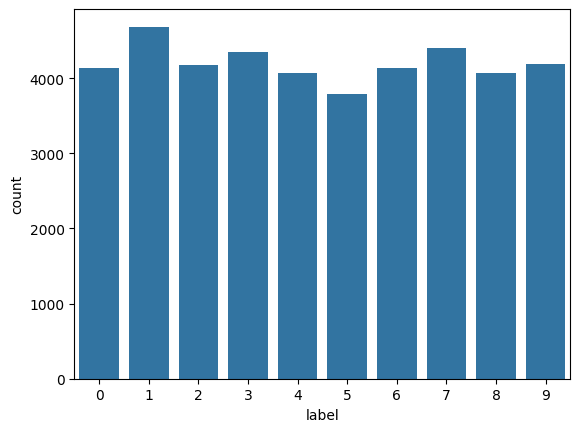

In [66]:
#Визуализация количества представителей каждого класса
sns.countplot(df_train, x='label')

In [68]:
#Процент представителей каждого класса от общего количества данных
np.round(df_train['label'].value_counts()/df_train.shape[0]*100, 2)

label
1    11.15
7    10.48
3    10.36
9     9.97
2     9.95
6     9.85
0     9.84
4     9.70
8     9.67
5     9.04
Name: count, dtype: float64

In [70]:
#Проверка на пропущенные значения
df_train.isnull().sum().sum()

0

In [72]:
#Перемещение столбца label в конец таблицы
label_train = df_train['label']
df_train = df_train.drop('label', axis=1)
df_train['label'] = label_train
df_train.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
#Проверка на наличие дубликатов
df_train.duplicated().sum()

0

### 2. Уменьшение размерности и обучение модели с применением метода главных компонент и метода опорных векторов соответственно

In [77]:
#Отделение целвевой переменной от признаков
y = df_train['label']
X = df_train.drop('label', axis=1)

In [79]:
#Поскольку в датасете содержится 785 признаков, логично уменьшить размерность пространства признаков. Для этого применим
#метод главных компонент (PCA)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.decomposition import PCA

In [81]:
#Разделение на обучающую и валидационную выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [83]:
#Стандартизация признаков
scaler = StandardScaler()

In [85]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [87]:
#Применение метода главных компонент. Укажем количество главных компонент равное 10
pca = PCA(n_components=10)
pca_X_train = pca.fit_transform(scaled_X_train)
pca_X_test = pca.transform(scaled_X_test)

In [89]:
#Обучение модели методом опорных векторов, оставляем параметры по умолчанию
model = SVC()

In [91]:
#Так как у нас стоит задача многоклассовой классификации, то для метода опорных векторов используем метод 'один против остальных'
ovr = OneVsRestClassifier(model)

In [93]:
#Обучение модели
ovr.fit(pca_X_train, y_train)

OneVsRestClassifier(estimator=SVC())

In [95]:
#Предсказание результатов для валидационной выборки
y_pred = ovr.predict(pca_X_test)

In [97]:
#Импорт библиотек для оценки качества модели
from sklearn.metrics import accuracy_score, classification_report

In [99]:
#Значение accuracy
accuracy_score(y_test, y_pred)

0.9160317460317461

In [101]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1200
           1       0.97      0.99      0.98      1389
           2       0.95      0.93      0.94      1294
           3       0.92      0.87      0.90      1355
           4       0.89      0.88      0.88      1222
           5       0.90      0.89      0.90      1085
           6       0.95      0.96      0.96      1256
           7       0.93      0.91      0.92      1359
           8       0.86      0.91      0.88      1209
           9       0.85      0.85      0.85      1231

    accuracy                           0.92     12600
   macro avg       0.91      0.92      0.91     12600
weighted avg       0.92      0.92      0.92     12600



In [103]:
X_final = df_test

In [105]:
scaled_X_final = scaler.transform(X_final)

In [107]:
pca_X_final = pca.transform(scaled_X_final)

In [119]:
y_final = ovr.predict(pca_X_final)

In [121]:
final = {'ImageId':np.arange(1,28001),
        'Label':y_final}
df_predict_final = pd.DataFrame(final)
df_predict_final.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,4
4,5,3


In [123]:
df_predict_final.to_csv('sample_submission.csv', index=False)

### После отправки данного csv файла в kaggle, получил точность 0.91357

In [63]:
#Поскольку целью данной задачи является получить точность не менее 0.93, попробуем увеличить количество главных компонент
#до 15. Проделываем аналогичные шаги.

In [109]:
#Применение метода главных компонент. Укажем количество главных компонент равное 15
pca_1 = PCA(n_components=15)
pca_X_train = pca_1.fit_transform(scaled_X_train)
pca_X_test = pca_1.transform(scaled_X_test)

In [111]:
#Обучение модели
ovr.fit(pca_X_train, y_train)

OneVsRestClassifier(estimator=SVC())

In [113]:
y_pred_1 = ovr.predict(pca_X_test)

In [115]:
accuracy_score(y_test, y_pred_1)

0.9434126984126984

In [117]:
print(classification_report(y_test, y_pred_1))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1200
           1       0.98      0.99      0.98      1389
           2       0.96      0.95      0.95      1294
           3       0.94      0.91      0.92      1355
           4       0.94      0.94      0.94      1222
           5       0.94      0.93      0.94      1085
           6       0.96      0.98      0.97      1256
           7       0.94      0.92      0.93      1359
           8       0.91      0.94      0.92      1209
           9       0.89      0.89      0.89      1231

    accuracy                           0.94     12600
   macro avg       0.94      0.94      0.94     12600
weighted avg       0.94      0.94      0.94     12600



In [121]:
X_final = df_test

In [123]:
scaled_X_final = scaler.transform(X_final)

In [131]:
pca_X_final = pca_1.transform(scaled_X_final)

In [133]:
y_final = ovr.predict(pca_X_final)

In [135]:
final = {'ImageId':np.arange(1,28001),
        'Label':y_final}
df_predict_final = pd.DataFrame(final)
df_predict_final.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,4
4,5,3


In [ ]:
df_predict_final.to_csv('sample_submission.csv', index=False)

### После отправки данного csv файла в kaggle, получил точность 0.94375